# 03 — Prognostic Workflow

This notebook demonstrates the **prognostic** use-case using the **XJTU-SY Bearing Datasets**:  
a multi-run ISA-JSON where each assay holds many repeated measurements taken across the bearing lifecycle.

**Covers:**
1. Load ISAWrapper (XJTU-SY — 15 studies, 52–161 runs each)
2. Navigate Bearing 1_1 → list runs
3. Variable overview — factor × run matrix
4. Lifecycle feature streaming (memory-safe generator)
5. Lifecycle plot — RMS trend over runs
6. Correlation analysis over lifecycle features
7. Explicit run loading (`load_dataframe(run_id=...)`)


In [1]:
%pip install -q pydantic pandas numpy scipy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import logging
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

logging.getLogger("isa_phm").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from isa_phm import ISAWrapper
from isa_phm.errors import DataFileError

ISA_JSON  = Path(r"E:\\XJTU-SY_Bearing_Datasets\\XJTU-SY Bearing Datasets-ISA-PHM.json").resolve()
DATA_ROOT = ISA_JSON.parent

print(f"Fixture : {ISA_JSON}")
print(f"Exists  : {ISA_JSON.exists()}")


Fixture : E:\XJTU-SY_Bearing_Datasets\XJTU-SY Bearing Datasets-ISA-PHM.json
Exists  : True


## 1. Load the wrapper (multi-run)

In [3]:
wrapper = ISAWrapper(
    path=ISA_JSON,
    data_root=DATA_ROOT,
    strict_validation=False,
    auto_fix=True,
)

ov = wrapper.investigation_overview()
print(f"Investigation : {ov.title}")
print(f"Studies       : {ov.n_studies}")
print(f"Experiment    : {ov.experiment_type}")


Investigation : XJTU-SY Bearing Datasets
Studies       : 15
Experiment    : prognostics-experiment


## 2. Navigate Bearing 1_1 — list runs

In the XJTU-SY dataset each assay holds one run per measurement file (52–161 files depending on the bearing).  
`assay.list_runs()` returns one `RunSummary` per run including the factor values at that run.


In [4]:
case1 = wrapper.study("Bearing 3_2")
print(f"Study      : {case1.title}")
print(f"Run count  : {case1.run_count}")
print(f"Has runs   : {case1.has_runs}  ← True = prognostic (N runs per assay)")

# Pick the first assay
assay_summaries = case1.list_assays()
assay = case1.assay(assay_summaries[0].assay_id)
assay_ov = assay.overview()
print(f"\nAssay : {assay_ov.assay_id}  /  Sensor : {assay_ov.sensor_alias}")

# List all runs
runs = assay.list_runs()
print(f"Runs  : {len(runs)}")
pd.DataFrame([r.model_dump() for r in runs]).head(5)


Study      : Bearing 3_2
Run count  : 2496
Has runs   : True  ← True = prognostic (N runs per assay)

Assay : a_st12_se01  /  Sensor : a_st12_se01
Runs  : 2496


,run_id,run_number,factor_values,raw_file_path,processed_file_path,n_measurement_params,n_processing_params
0,run_0001,1,"{'Fault Type': 'Inner Race, Ball Cage and Oute...",E:\XJTU-SY_Bearing_Datasets\Data_split_per_fil...,None,3,0
1,run_0002,2,"{'Fault Type': 'Inner Race, Ball Cage and Oute...",E:\XJTU-SY_Bearing_Datasets\Data_split_per_fil...,None,3,0
2,run_0003,3,"{'Fault Type': 'Inner Race, Ball Cage and Oute...",E:\XJTU-SY_Bearing_Datasets\Data_split_per_fil...,None,3,0
3,run_0004,4,"{'Fault Type': 'Inner Race, Ball Cage and Oute...",E:\XJTU-SY_Bearing_Datasets\Data_split_per_fil...,None,3,0
4,run_0005,5,"{'Fault Type': 'Inner Race, Ball Cage and Oute...",E:\XJTU-SY_Bearing_Datasets\Data_split_per_fil...,None,3,0


## 3. Variable overview — factor × run matrix

For prognostic data, `case1.variable_overview()` shows how the controlled factors (speed, load, …)  
are recorded across all runs in a study.


In [5]:
# variable_overview() is on StudyProxy — shows factor values per (assay, run)
var_ov = case1.variable_overview()
display(var_ov.head(10))

,assay_id,run_id,run_number,sensor_alias,measurement_type,Fault Type,Bearing Lifetime,Motor speed,Pressure Axial,Pressure Radial,processed_file_exists
0,a_st12_se01,run_0001,1,a_st12_se01,Vibration,"Inner Race, Ball Cage and Outer Race",2496 min,2400 RPM,10 kN,10 kN,False
1,a_st12_se01,run_0002,2,a_st12_se01,Vibration,"Inner Race, Ball Cage and Outer Race",2495 min,2400 RPM,10 kN,10 kN,False
2,a_st12_se01,run_0003,3,a_st12_se01,Vibration,"Inner Race, Ball Cage and Outer Race",2494 min,2400 RPM,10 kN,10 kN,False
3,a_st12_se01,run_0004,4,a_st12_se01,Vibration,"Inner Race, Ball Cage and Outer Race",2493 min,2400 RPM,10 kN,10 kN,False
4,a_st12_se01,run_0005,5,a_st12_se01,Vibration,"Inner Race, Ball Cage and Outer Race",2492 min,2400 RPM,10 kN,10 kN,False
5,a_st12_se01,run_0006,6,a_st12_se01,Vibration,"Inner Race, Ball Cage and Outer Race",2491 min,2400 RPM,10 kN,10 kN,False
6,a_st12_se01,run_0007,7,a_st12_se01,Vibration,"Inner Race, Ball Cage and Outer Race",2490 min,2400 RPM,10 kN,10 kN,False
7,a_st12_se01,run_0008,8,a_st12_se01,Vibration,"Inner Race, Ball Cage and Outer Race",2489 min,2400 RPM,10 kN,10 kN,False
8,a_st12_se01,run_0009,9,a_st12_se01,Vibration,"Inner Race, Ball Cage and Outer Race",2488 min,2400 RPM,10 kN,10 kN,False
9,a_st12_se01,run_0010,10,a_st12_se01,Vibration,"Inner Race, Ball Cage and Outer Race",2487 min,2400 RPM,10 kN,10 kN,False


## 4. Lifecycle feature streaming

`assay.lifecycle_features()` loads all run CSVs in parallel (threads) and computes 8 scalar features per run.  
`n_workers` controls thread count — `None` (default) picks `min(32, cpu_count + 4)` automatically.  
With the XJTU-SY dataset the raw files are present on disk, so real signals will be loaded.  
A synthetic fallback is included in case the external drive is unavailable.


In [6]:
import os
import time
from isa_phm.utils import compute_features

# n_workers controls parallel CSV loading.
# - None  → auto: min(32, cpu_count + 4)   good for SSD / NVMe
# - 1     → sequential                      best for single HDD / USB drive
# - 4–8   → moderate parallelism            try if drive supports concurrent reads
N_WORKERS = None
print(f"CPU count: {os.cpu_count()}  →  will use up to {min(32, (os.cpu_count() or 1) + 4)} threads")

t0 = time.perf_counter()
lifecycle_df = assay.lifecycle_features(file_type="raw", n_workers=N_WORKERS)
elapsed = time.perf_counter() - t0

if not lifecycle_df.empty:
    print(f"Loaded real lifecycle: {lifecycle_df.shape}  ({elapsed:.1f}s)")
else:
    print(f"CSV files not found ({elapsed:.1f}s) — computing features from synthetic signals")

    rng = np.random.default_rng(0)
    t = np.linspace(0, 1.0, 4096)
    n_runs = len(runs)

    rows = []
    for i, run_summary in enumerate(runs):
        signal = (
            np.sin(2 * np.pi * 29.3 * t) * (1 + 2 * i / max(n_runs - 1, 1))
            + 0.3 * rng.standard_normal(len(t))
        )
        row = compute_features(signal)
        row["run_id"]     = run_summary.run_id
        row["run_number"] = run_summary.run_number
        rows.append(row)

    lifecycle_df = pd.DataFrame(rows)
    print(f"Synthetic lifecycle: {lifecycle_df.shape}")

display(lifecycle_df.head())


CPU count: 24  →  will use up to 28 threads
Loaded real lifecycle: (2496, 17)  (180.6s)


,run_id,run_number,study_id,assay_id,rms,max,mean,peak2peak,kurtosis,std,crest_factor,skewness,fv_Fault Type,fv_Bearing Lifetime,fv_Motor speed,fv_Pressure Axial,fv_Pressure Radial
0,run_0001,1,c5f2fce3-8d93-4017-bf77-e773c11787e7,a_st12_se01,0.884647,5.032480,0.006879,10.035062,0.694631,0.884620,5.688690,0.016443,"Inner Race, Ball Cage and Outer Race",2496 min,2400 RPM,10 kN,10 kN
1,run_0002,2,c5f2fce3-8d93-4017-bf77-e773c11787e7,a_st12_se01,0.891584,4.864585,0.010553,10.346282,0.718650,0.891522,6.148266,0.011191,"Inner Race, Ball Cage and Outer Race",2495 min,2400 RPM,10 kN,10 kN
2,run_0003,3,c5f2fce3-8d93-4017-bf77-e773c11787e7,a_st12_se01,0.791156,3.789747,0.014353,7.891881,0.602141,0.791025,5.184992,0.073859,"Inner Race, Ball Cage and Outer Race",2494 min,2400 RPM,10 kN,10 kN
3,run_0004,4,c5f2fce3-8d93-4017-bf77-e773c11787e7,a_st12_se01,0.746782,3.920186,-0.003069,7.201207,0.570357,0.746776,5.249437,0.089632,"Inner Race, Ball Cage and Outer Race",2493 min,2400 RPM,10 kN,10 kN
4,run_0005,5,c5f2fce3-8d93-4017-bf77-e773c11787e7,a_st12_se01,0.859828,4.212880,0.026104,8.515310,0.620220,0.859432,5.003827,0.019330,"Inner Race, Ball Cage and Outer Race",2492 min,2400 RPM,10 kN,10 kN


## 5. Lifecycle plot — RMS trend

Plot one scalar feature (default: RMS) over all runs to see the degradation trend.

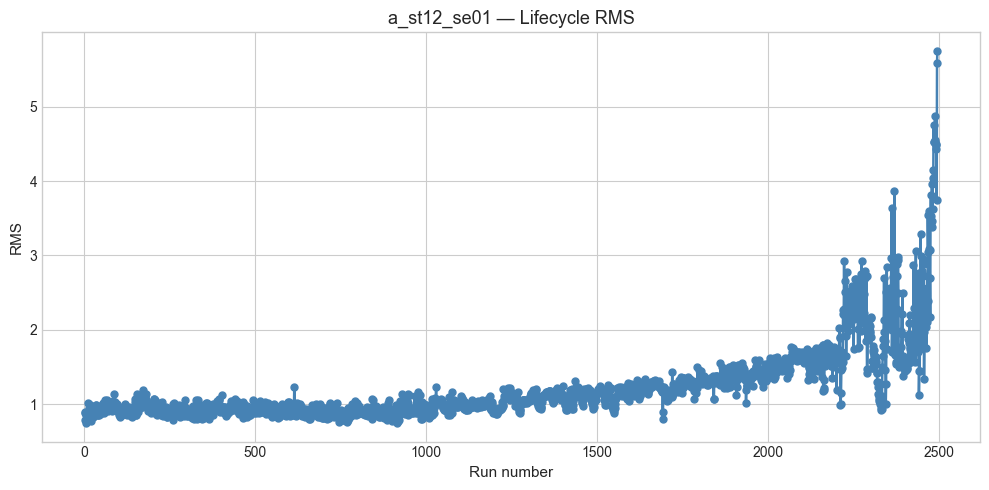

In [7]:
from isa_phm.errors import PlotError
from isa_phm.plotter import ISAPlotter

try:
    fig = assay.plot_lifecycle(feature="rms", file_type="raw", n_workers=N_WORKERS)
    plt.show()
except (DataFileError, PlotError):
    # Fall back to plotter with our pre-computed lifecycle
    plotter = ISAPlotter()
    fig = plotter.plot_lifecycle(
        lifecycle_df,
        feature="rms",
        title=f"{assay_ov.assay_id} — RMS Lifecycle (synthetic)",
    )
    plt.tight_layout()
    plt.show()


## 6. Correlation analysis

`assay.plot_correlation()` computes a Pearson correlation heatmap across the scalar lifecycle features —  
useful for identifying redundant health indicators before selecting a prognostic index.

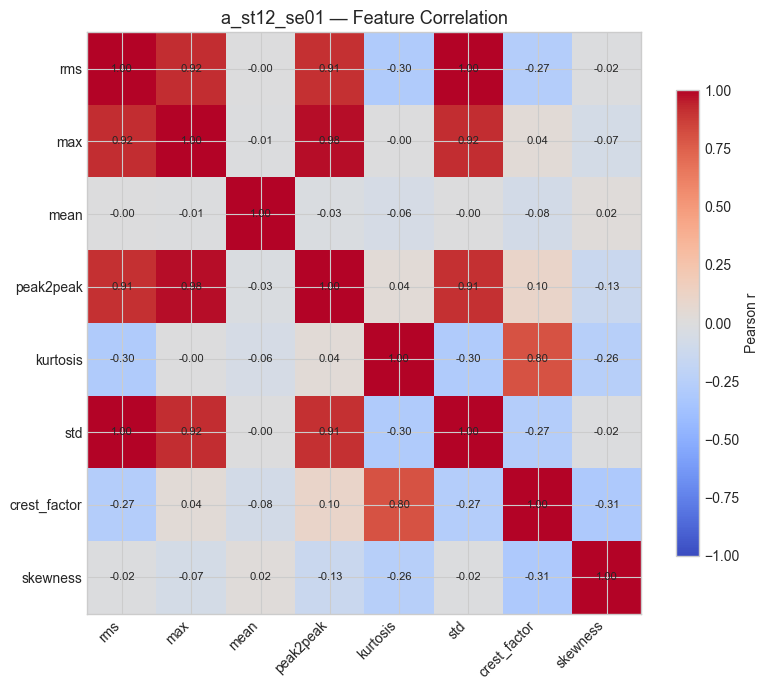

In [8]:
FEAT_COLS = ["rms", "max", "mean", "peak2peak", "kurtosis", "std", "crest_factor", "skewness"]

try:
    fig = assay.plot_correlation(file_type="raw", n_workers=N_WORKERS)
    plt.show()
except (DataFileError, PlotError):
    plotter = ISAPlotter()
    feat_cols = [c for c in FEAT_COLS if c in lifecycle_df.columns]
    fig = plotter.plot_correlation(
        lifecycle_df[feat_cols],
        title=f"{assay_ov.assay_id} — Feature Correlation (synthetic)",
    )
    plt.tight_layout()
    plt.show()


## 7. Explicit run loading

For prognostic data, `assay.load_dataframe(run_id="run_001")` loads a single run by ID.  
This is required when there are multiple runs — omitting `run_id` raises `AmbiguousRunError`.


In [9]:
from isa_phm.errors import AmbiguousRunError

# With multiple runs, omitting run_id raises AmbiguousRunError
try:
    df_ambiguous = assay.load_dataframe()
except AmbiguousRunError as exc:
    print(f"[AmbiguousRunError] {exc}")
    print("→ Specify run_id explicitly")
except DataFileError as exc:
    print(f"[DataFileError] {exc}")

# Load the first run explicitly
try:
    first_run_id = runs[0].run_id
    df_run1 = assay.load_dataframe(run_id=first_run_id, file_type="raw")
    print(f"\nRun '{first_run_id}' loaded: {df_run1.shape}")
    display(df_run1.head())
except DataFileError as exc:
    print(f"\n[DataFileError] run '{runs[0].run_id}': {exc}")
    print("(Expected for demo fixture with D:\\DPL\\... external drive paths)")

[AmbiguousRunError] Assay 'a_st12_se01' has 2496 runs. Specify run_id= explicitly. Available: ['run_0001', 'run_0002', 'run_0003', 'run_0004', 'run_0005', 'run_0006', 'run_0007', 'run_0008', 'run_0009', 'run_0010', 'run_0011', 'run_0012', 'run_0013', 'run_0014', 'run_0015', 'run_0016', 'run_0017', 'run_0018', 'run_0019', 'run_0020', 'run_0021', 'run_0022', 'run_0023', 'run_0024', 'run_0025', 'run_0026', 'run_0027', 'run_0028', 'run_0029', 'run_0030', 'run_0031', 'run_0032', 'run_0033', 'run_0034', 'run_0035', 'run_0036', 'run_0037', 'run_0038', 'run_0039', 'run_0040', 'run_0041', 'run_0042', 'run_0043', 'run_0044', 'run_0045', 'run_0046', 'run_0047', 'run_0048', 'run_0049', 'run_0050', 'run_0051', 'run_0052', 'run_0053', 'run_0054', 'run_0055', 'run_0056', 'run_0057', 'run_0058', 'run_0059', 'run_0060', 'run_0061', 'run_0062', 'run_0063', 'run_0064', 'run_0065', 'run_0066', 'run_0067', 'run_0068', 'run_0069', 'run_0070', 'run_0071', 'run_0072', 'run_0073', 'run_0074', 'run_0075', 'run_

,time,value,study_id,assay_id,run_id,sensor_alias,measurement_type,file_type
0,0.000000,0.322592,c5f2fce3-8d93-4017-bf77-e773c11787e7,a_st12_se01,run_0001,a_st12_se01,Vibration,raw
1,0.000039,-0.522924,c5f2fce3-8d93-4017-bf77-e773c11787e7,a_st12_se01,run_0001,a_st12_se01,Vibration,raw
2,0.000078,-0.216854,c5f2fce3-8d93-4017-bf77-e773c11787e7,a_st12_se01,run_0001,a_st12_se01,Vibration,raw
3,0.000117,0.186336,c5f2fce3-8d93-4017-bf77-e773c11787e7,a_st12_se01,run_0001,a_st12_se01,Vibration,raw
4,0.000156,-0.791061,c5f2fce3-8d93-4017-bf77-e773c11787e7,a_st12_se01,run_0001,a_st12_se01,Vibration,raw


---

## What's next?

| Notebook | Topic |
|---|---|
| `01_getting_started.ipynb` | API tour — investigation, study, assay navigation |
| `02_diagnostic_workflow.ipynb` | Single-run signal analysis, FFT, missing-value report |

For real prognostic analysis, point `data_root` to the directory containing the CSV files and all `lifecycle_features()` / `plot_*` calls will work end-to-end without synthetic fallbacks.